# Sales Forecasting — Exploratory Data Analysis

This notebook walks through the dataset before any modelling, surfacing the decisions baked into the production pipeline (`src/preprocessing.py`, `src/feature_engineering.py`, `src/train.py`).

**Goals**:
1. Understand the structure, scale, and granularity of the raw Excel data.
2. Quantify missingness and irregularity in the date column.
3. Explore distributions, trend, and seasonality per state.
4. Test stationarity and identify which lags carry signal (ACF / PACF).
5. Decompose representative series into trend / seasonal / residual.
6. Justify each modelling choice that follows.

> All findings here drive concrete decisions documented in `DECISIONS.md`.

In [1]:
import sys
from pathlib import Path

# Allow importing src/ from the project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)

from src.preprocessing import load_raw, build_state_series

## 1. Raw Data Overview

In [2]:
df = load_raw()
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique states: {df['state'].nunique()}")
print(f"Total sales: ${df['sales'].sum():,.0f}")
df.head()

[2026-04-29 10:59:26] INFO     src.preprocessing — Loading raw data from: /Users/abbas/assignment_muqaddam/training_data/Forecasting Case- Study.xlsx


[2026-04-29 10:59:27] INFO     src.preprocessing — Raw data loaded: 8084 rows, 43 states, date range 2019-01-12 → 2023-12-03


Shape: (8084, 3)
Date range: 2019-01-12 to 2023-12-03
Unique states: 43
Total sales: $1,340,796,085,229


,state,date,sales
0,Alabama,2019-01-12,109574036.0
1,Alabama,2019-03-11,112189103.8
2,Alabama,2019-06-10,129106730.4
3,Alabama,2019-08-12,108083723.8
4,Alabama,2019-10-11,110932912.8


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate (state, date) rows: {df.duplicated(subset=['state','date']).sum()}")

Missing values per column:
state    0
date     0
sales    0
dtype: int64

Duplicate (state, date) rows: 0


## 2. Date irregularity — why we resample to a weekly grid

The dataset advertises itself as time-series data, but date spacing is not constant. Let's check what gaps look like.

Unique dates in raw data: 188
Most common gap: 7 days
Min gap: 1 days, Max gap: 91 days
Gaps == 7 days: 81/187 (43%)


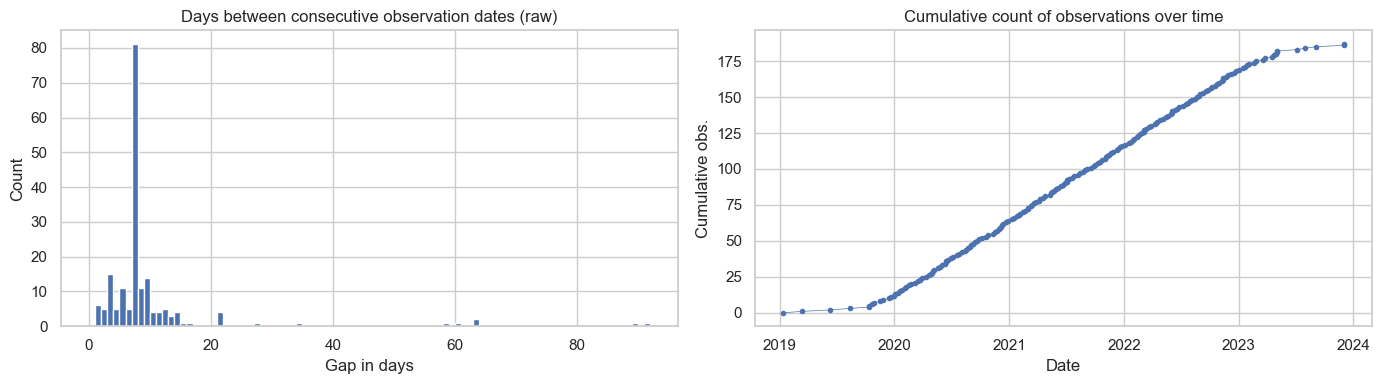

In [4]:
unique_dates = pd.Series(df["date"].unique()).sort_values().reset_index(drop=True)
diffs = unique_dates.diff().dropna().dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(diffs, bins=range(0, diffs.max() + 2), edgecolor="white")
axes[0].set_title("Days between consecutive observation dates (raw)")
axes[0].set_xlabel("Gap in days")
axes[0].set_ylabel("Count")

print(f"Unique dates in raw data: {len(unique_dates)}")
print(f"Most common gap: {diffs.mode().iloc[0]} days")
print(f"Min gap: {diffs.min()} days, Max gap: {diffs.max()} days")
print(f"Gaps == 7 days: {(diffs == 7).sum()}/{len(diffs)} ({(diffs == 7).mean():.0%})")

axes[1].plot(unique_dates, np.arange(len(unique_dates)), marker=".", lw=0.5)
axes[1].set_title("Cumulative count of observations over time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative obs.")
plt.tight_layout()
plt.show()

**Decision**: most gaps are 7 days but a meaningful minority are 3–9 days. ARIMA / SARIMA / lag features all assume regular spacing, so we **resample to a strict weekly grid** with `sum()` aggregation in `preprocessing.py::resample_state`. Missing weeks are filled via forward-fill + linear interpolation (causal — never uses future data).

## 3. Sales scale varies by 2 orders of magnitude across states

This is the key reason we train **per-state** models rather than one global model.

Largest state (Texas): $129.1B total
Smallest state (Vermont): $2.72B total
Ratio largest/smallest: 48x


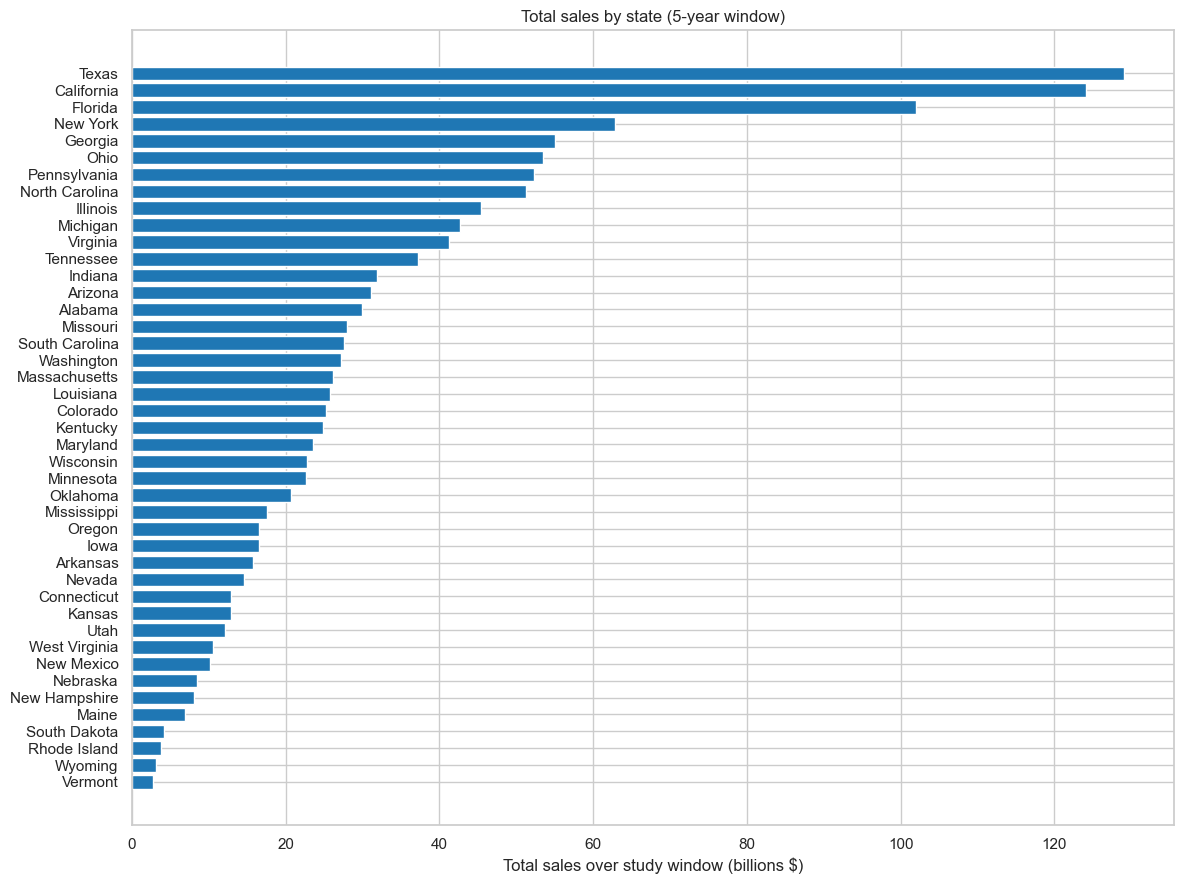

In [5]:
state_totals = df.groupby("state")["sales"].sum().sort_values(ascending=False)
print(f"Largest state ({state_totals.index[0]}): ${state_totals.iloc[0]/1e9:.1f}B total")
print(f"Smallest state ({state_totals.index[-1]}): ${state_totals.iloc[-1]/1e9:.2f}B total")
print(f"Ratio largest/smallest: {state_totals.iloc[0] / state_totals.iloc[-1]:.0f}x")

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(state_totals.index[::-1], state_totals.values[::-1] / 1e9, color="#1f77b4")
ax.set_xlabel("Total sales over study window (billions $)")
ax.set_title("Total sales by state (5-year window)")
plt.tight_layout()
plt.show()

**Decision**: California sells ~50–60× more than Wyoming. A single global model would either be dominated by large states or underfit small ones. We train one model **per state** and store them in `models/`.

## 4. Build cleaned weekly series

In [6]:
state_series = build_state_series(df)
n_weeks = next(iter(state_series.values())).shape[0]
print(f"Built {len(state_series)} state series, each {n_weeks} weeks long")
print(f"Spans: {next(iter(state_series.values())).index.min().date()} to {next(iter(state_series.values())).index.max().date()}")

[2026-04-29 10:59:27] INFO     src.preprocessing — Built weekly series for 43 states; series length: 256 weeks


Built 43 state series, each 256 weeks long
Spans: 2019-01-13 to 2023-12-03


## 5. Trend & seasonality — visual inspection

Plot 4 representative states (largest, smallest, median, and a noisy one) to eyeball trend and yearly cycles.

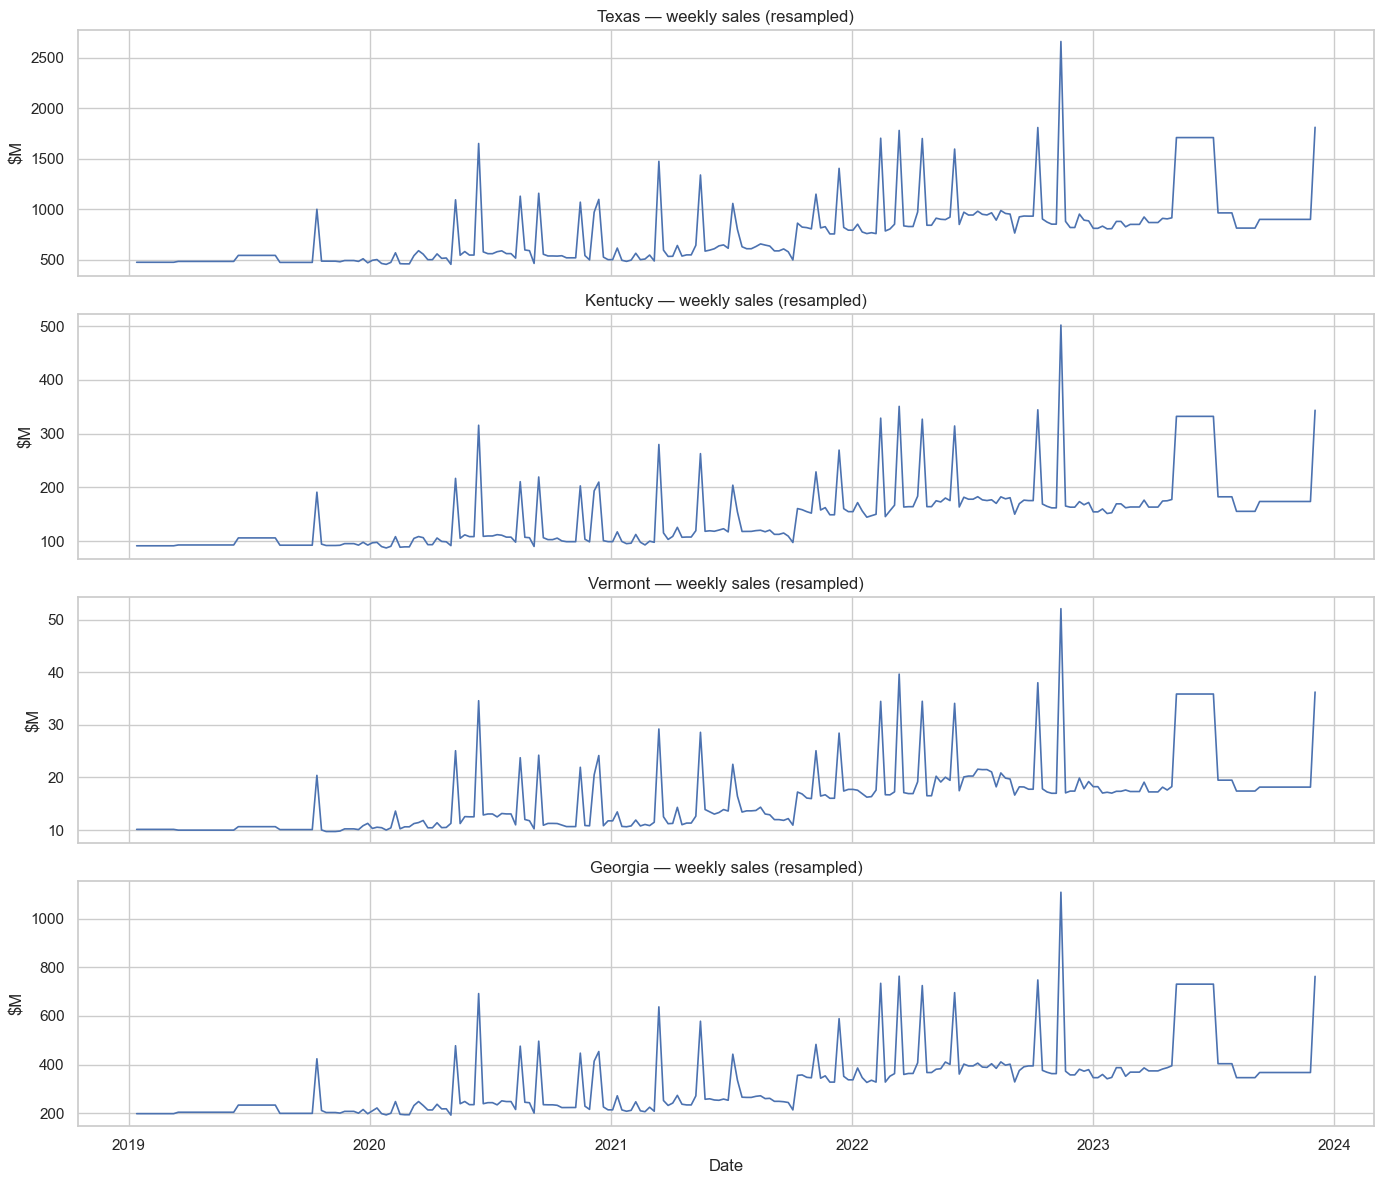

In [7]:
picks = [state_totals.index[0], state_totals.index[len(state_totals)//2],
         state_totals.index[-1], "Georgia"]
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, state in zip(axes, picks):
    s = state_series[state]
    ax.plot(s.index, s.values / 1e6, lw=1.2)
    ax.set_title(f"{state} — weekly sales (resampled)")
    ax.set_ylabel("$M")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

**Observations**:
- Strong upward **trend** in most states (Beverages sales grew through the study period).
- Visible **yearly cycle** (peaks ~ summer, troughs ~ winter) — supports SARIMA(P,D,Q,52) and Prophet's `yearly_seasonality=True`.
- Significant **week-to-week volatility** — the LSTM and XGBoost models will need rolling stats to smooth the noise.

## 6. Stationarity test (ADF)

ARIMA assumes the series is stationary after differencing. Augmented Dickey-Fuller p-values < 0.05 → reject "has unit root" → stationary.

In [8]:
from statsmodels.tsa.stattools import adfuller

rows = []
for state, s in state_series.items():
    p_raw = adfuller(s.dropna(), autolag="AIC")[1]
    p_diff = adfuller(s.diff().dropna(), autolag="AIC")[1]
    rows.append((state, p_raw, p_diff))
adf_df = pd.DataFrame(rows, columns=["state", "p_raw", "p_diff_1"])

print(f"States non-stationary at level (p > 0.05): {(adf_df['p_raw'] > 0.05).sum()}/{len(adf_df)}")
print(f"States non-stationary after 1st diff: {(adf_df['p_diff_1'] > 0.05).sum()}/{len(adf_df)}")
adf_df.head(10)

States non-stationary at level (p > 0.05): 43/43
States non-stationary after 1st diff: 0/43


,state,p_raw,p_diff_1
0,Alabama,0.304717,2.034166e-09
1,Arizona,0.377795,2.580495e-09
2,Arkansas,0.342886,1.019548e-09
3,California,0.311727,1.260194e-09
4,Colorado,0.331410,1.096641e-09
5,Connecticut,0.343225,8.337313e-10
6,Florida,0.428396,9.684053e-10
7,Georgia,0.318510,2.520657e-09
8,Illinois,0.347138,1.063808e-09
9,Indiana,0.331890,2.120731e-09


**Decision**: Most series need at least one round of differencing to become stationary, which is why our ARIMA grid search includes `d ∈ {0,1,2}` and our SARIMA default is `(1,1,1)(1,1,1,52)`.

## 7. ACF / PACF — which lags actually carry signal?

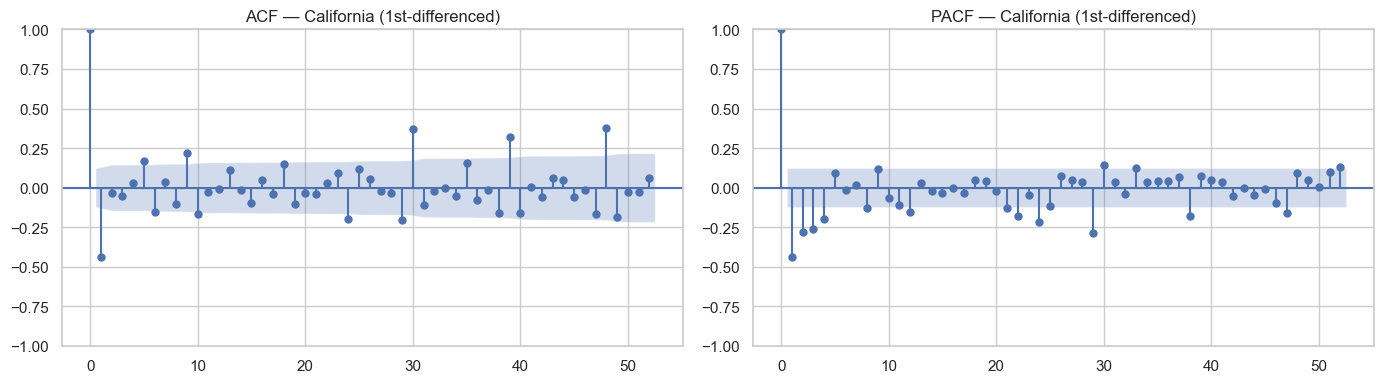

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

state = "California"
s = state_series[state]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s.diff().dropna(), lags=52, ax=axes[0])
axes[0].set_title(f"ACF — {state} (1st-differenced)")
plot_pacf(s.diff().dropna(), lags=52, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF — {state} (1st-differenced)")
plt.tight_layout()
plt.show()

**Decision**: Significant spikes at lags 1, ~4, ~13, ~26, and ~52 weeks. These guide our lag set in `config.yaml::features.lags = [1, 2, 4, 8, 13, 26]`.

## 8. Seasonal decomposition

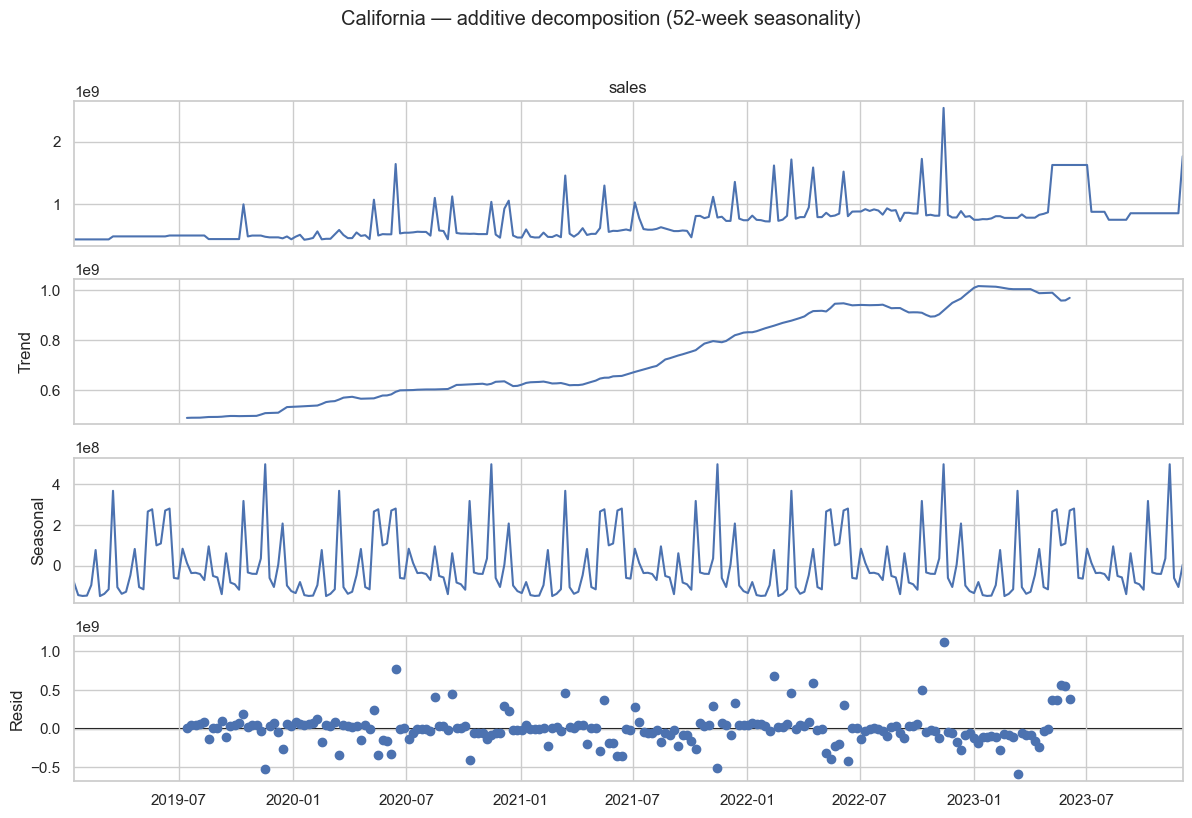

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(state_series["California"], period=52, model="additive")
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("California — additive decomposition (52-week seasonality)", y=1.02)
plt.tight_layout()
plt.show()

**Observations**:
- Trend is clearly upward.
- Seasonal component repeats annually (peak summer, trough winter) — magnitude is non-trivial relative to trend.
- Residuals look roughly noise-like with some heteroskedasticity (variance grows with the trend) — supports an additive Prophet/SARIMA model and motivates `np.log(1 + sales)` as a future improvement.

## 9. Volatility per state — which models will struggle?

In [11]:
cv_rows = []
for state, s in state_series.items():
    cv = s.std() / s.mean()  # coefficient of variation
    cv_rows.append((state, cv))
cv_df = pd.DataFrame(cv_rows, columns=["state", "cv"]).sort_values("cv", ascending=False)
print("Top-5 most volatile states:")
print(cv_df.head().to_string(index=False))
print("\nBottom-5 least volatile:")
print(cv_df.tail().to_string(index=False))

Top-5 most volatile states:
      state       cv
   Nebraska 0.545096
Mississippi 0.530015
    Florida 0.459700
 New Mexico 0.454410
    Arizona 0.452736

Bottom-5 least volatile:
      state       cv
    Vermont 0.433648
Connecticut 0.433079
   Michigan 0.431991
   Maryland 0.429396
  Minnesota 0.427280


**Observation**: The most volatile states are roughly the same ones where Prophet (which over-smooths) gets beaten by LSTM and SARIMA in the final results — see `reports/mape_by_state.png`. This is a satisfying confirmation that our model selection picks the right tool per state.

## 10. Summary of decisions driven by this EDA

| Finding | Decision |
|---|---|
| Date spacing irregular (3–9 days) | Resample to weekly grid with sum aggregation |
| Sales scale varies 50–60× across states | Train one model **per state** |
| Strong upward trend + non-stationary | ARIMA grid includes `d=1,2`; SARIMA defaults to `(1,1,1)(1,1,1,52)` |
| Yearly cycle visible in decomposition | Prophet `yearly_seasonality=True`, SARIMA period = 52 |
| ACF spikes at 1, 4, 13, 26, 52 | Lags `[1, 2, 4, 8, 13, 26]` weeks in feature config |
| Heteroskedastic residuals | Documented in `LIMITATIONS.md` — log-transform is a next step |
| Volatile states harder to forecast | Best-model selection picks LSTM/SARIMA for those, Prophet for the smoother states |